# Cell–cell communication with `sceleto.interaction`

`sceleto.interaction` infers ligand–receptor–mediated signaling between cell groups from
single-cell data. It is a Python port of **CellChat** (Jin *et al.*, *Nat. Commun.* 2021)
built directly on `AnnData`, reproducing CellChat's core numerics — communication
probabilities, permutation *p*-values, pathway aggregation, network centrality, and
communication-pattern (NMF) decomposition — with the CellChatDB (human/mouse/zebrafish)
bundled, so no R runtime is required.

This tutorial follows the official CellChat vignette so results can be compared against the
R original.

> **Attribution / license.** This module is a port of [CellChat](https://github.com/jinworks/CellChat)
> (GPL-3.0). Please cite Jin *et al.*, *Nat. Commun.* 2021 when using it. The bundled CellChatDB
> and the algorithm are derived from that work.

## Data

We use the **CellChat human-skin dataset** (scRNA-seq of skin from patients with atopic
dermatitis; [figshare 24470719](https://figshare.com/articles/dataset/scRNA-seq_data_of_human_skin_from_patients_with_atopic_dermatitis/24470719),
file `data_humanSkin.rda`). As in the CellChat single-dataset vignette we keep the **lesional
(LS)** cells only — 5,011 cells across 12 cell groups, log-normalized.

The `.rda` is an R object; convert it to `AnnData` once (in R):

```r
library(Matrix)
load("data_humanSkin.rda")                 # -> data_humanSkin$data (genes x cells), $meta
use  <- rownames(data_humanSkin$meta)[data_humanSkin$meta$condition == "LS"]
writeMM(data_humanSkin$data[, use], "matrix.mtx")
writeLines(rownames(data_humanSkin$data), "genes.txt")
writeLines(use, "barcodes.txt")
write.csv(data_humanSkin$meta[use, ], "meta.csv")
```

then build `humanSkin_LS.h5ad` from `matrix.mtx` + `meta.csv` (cells × genes, `obs["labels"]`
holds the cell-group column). The rest of this tutorial reads that file.

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import sceleto.interaction as ix

sc.settings.verbosity = 0

In [2]:
adata = sc.read_h5ad("humanSkin_LS.h5ad")
adata.obs["labels"] = adata.obs["labels"].astype("category")
print(adata)
adata.obs["labels"].value_counts()

AnnData object with n_obs × n_vars = 5011 × 17328
    obs: 'patient.id', 'condition', 'labels'


labels
APOE+ FIB       1228
FBN1+ FIB        813
TC               765
CD40LG+ TC       630
Inflam. FIB      484
cDC2             294
Inflam. TC       266
COL11A1+ FIB     181
cDC1             121
Inflam. DC        81
NKT               81
LC                67
Name: count, dtype: int64

## 1. Build the `CellComm` object and infer communication

The pipeline mirrors CellChat's workflow and is chainable (each step returns `self`):

- `identify_overexpressed()` — over-expressed genes → significant ligand–receptor pairs
- `compute_communication()` — LR-level probability + permutation *p*-values (parallel over `n_jobs`)
- `compute_communication_pathway()` — collapse LR pairs into signaling pathways
- `aggregate()` — cell-group × cell-group aggregated network (weight & count)

In [3]:
cc = ix.CellComm(adata, groupby="labels", species="human")
cc.identify_overexpressed()
cc.compute_communication(nboot=100, n_jobs=8, seed=1)
cc.compute_communication_pathway()
cc.aggregate()

print("cell groups :", list(cc.group_names))
print("LR pairs    :", len(cc.LRsig))
print("pathways    :", len(cc.netP["pathways"]))

[interaction] normalized 539 gene symbols onto CellChatDB canonical symbols (alias/case)


[interaction] 950 over-expressed genes → 1650 significant L-R pairs


[interaction] communication inference done: 1650 pairs, 12 groups
[interaction] 33 signaling pathways (172 with no significant communication dropped)
cell groups : ['APOE+ FIB', 'CD40LG+ TC', 'COL11A1+ FIB', 'FBN1+ FIB', 'Inflam. DC', 'Inflam. FIB', 'Inflam. TC', 'LC', 'NKT', 'TC', 'cDC1', 'cDC2']
LR pairs    : 1650
pathways    : 33


## 2. The aggregated cell–cell communication network

`cc.weight` (interaction strength) and `cc.count` (number of significant LR links) are
group × group matrices. Visualize them as a circular network and a heatmap.

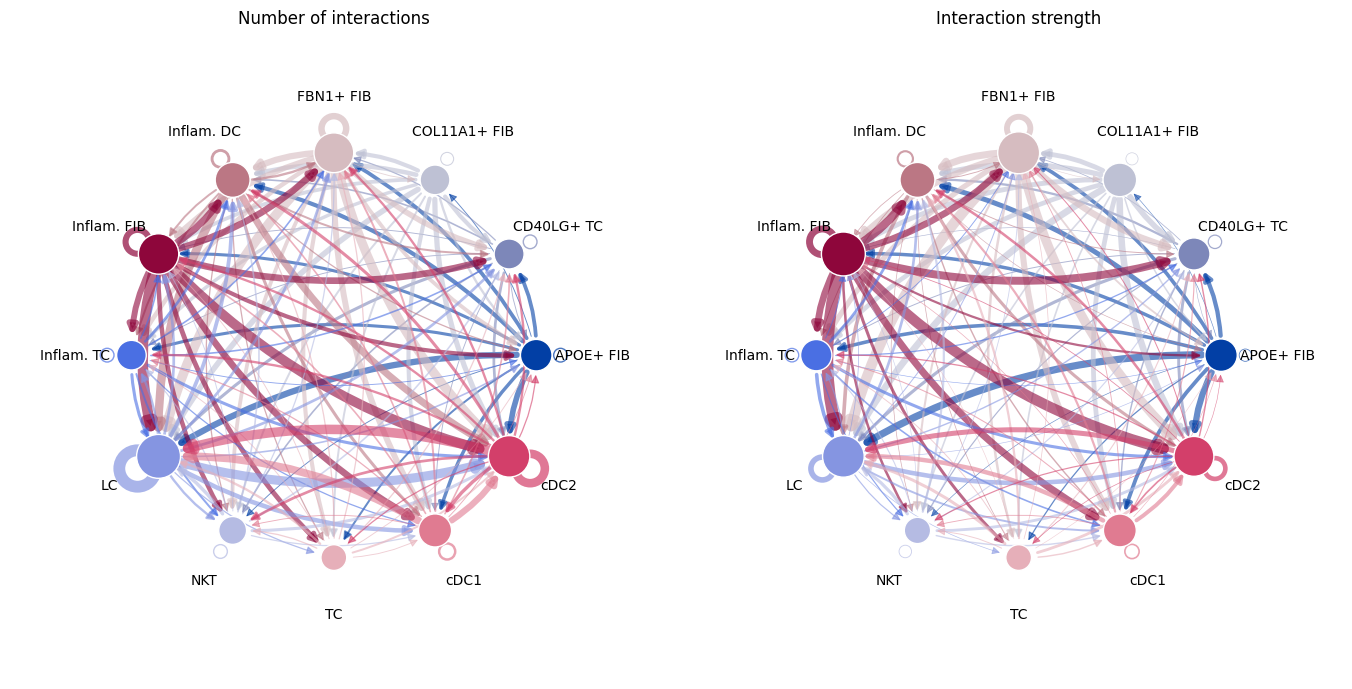

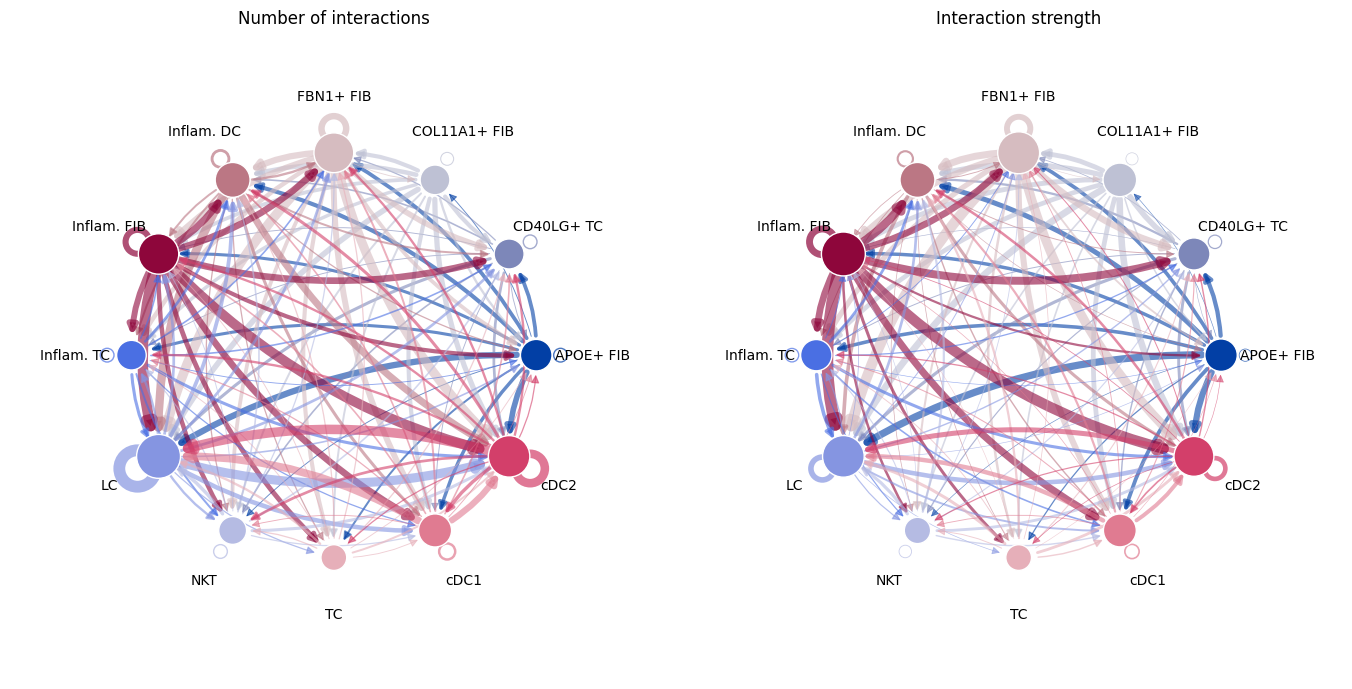

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
ix.plot_network_circle(cc.count,  cc.group_names, ax=axes[0], title="Number of interactions")
ix.plot_network_circle(cc.weight, cc.group_names, ax=axes[1], title="Interaction strength")
fig

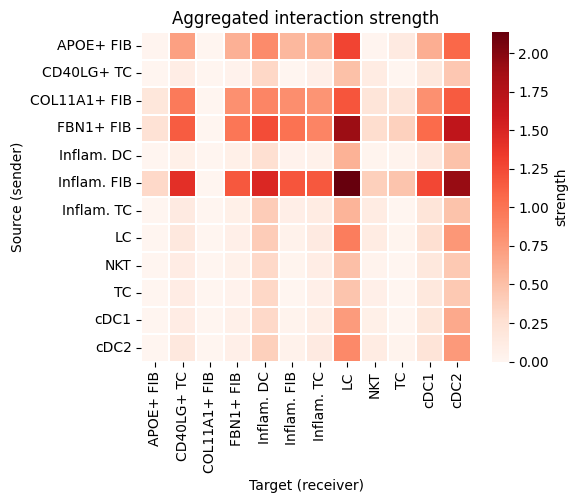

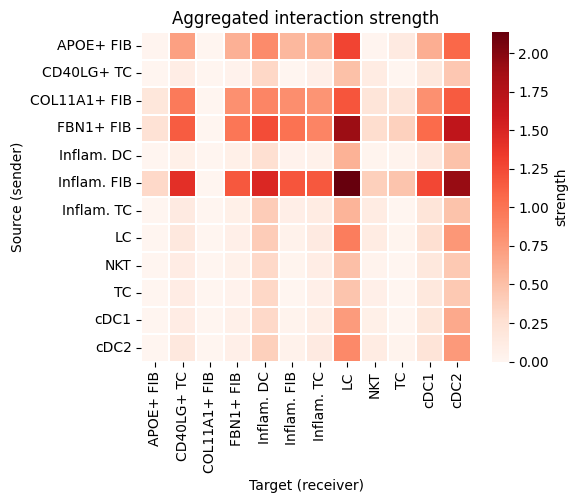

In [5]:
ix.plot_heatmap(cc.weight, cc.group_names, title="Aggregated interaction strength")

## 3. Rank signaling pathways by information flow

`rank_net()` ranks pathways by total communication probability (overall information flow).

pathway_name      flow
    COLLAGEN 27.853288
         MIF 15.083548
     LAMININ  1.929232
         FN1  1.818125
      MHC-II  1.775536
     ANNEXIN  1.264973
        CypA  1.028718
    GALECTIN  0.737726
         APP  0.690152
        CXCL  0.650261


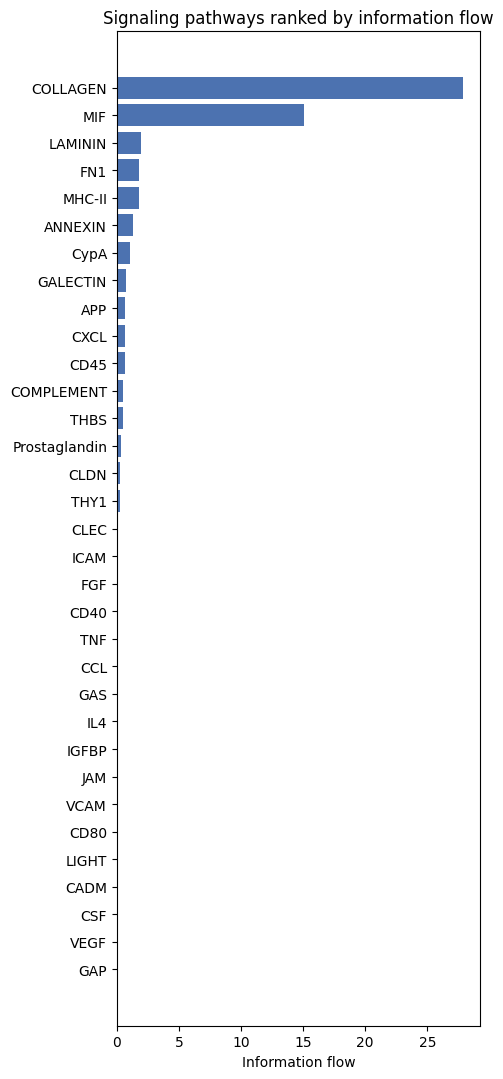

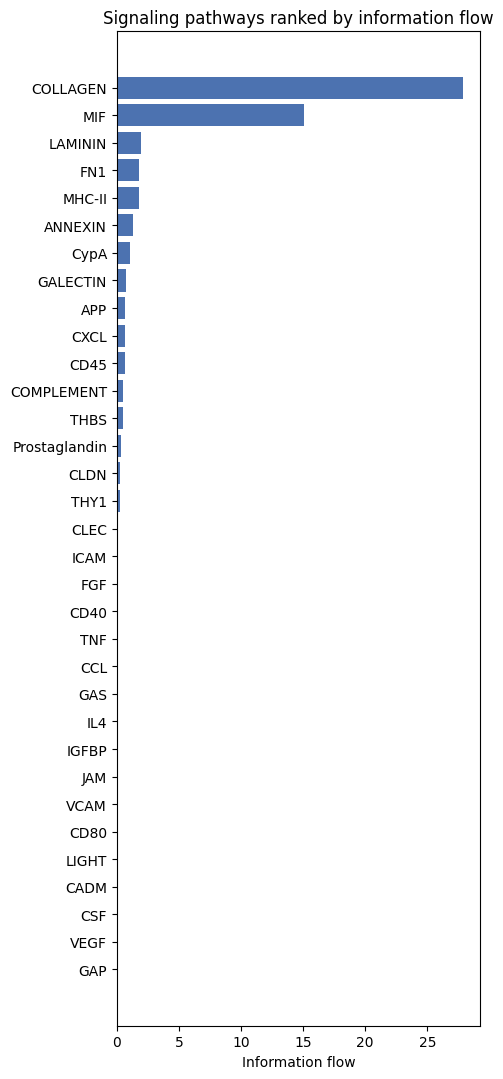

In [6]:
ranking = cc.rank_net()
print(ranking.head(10).to_string(index=False))
ix.plot_rank_net(ranking, title="Signaling pathways ranked by information flow")

## 4. Zoom into one signaling pathway

`MIF` is among the top pathways here. `plot_aggregate` draws the group-level network for a
single pathway; `contribution` breaks the pathway down into its individual L-R pairs.

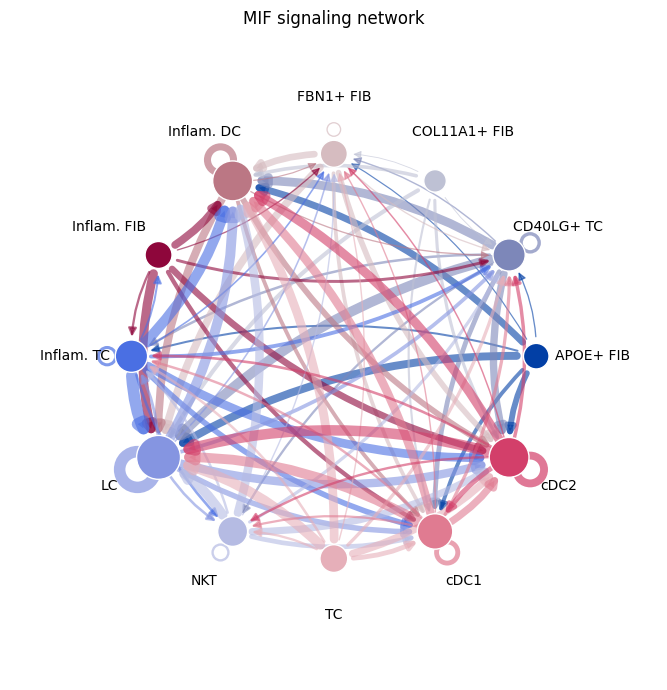

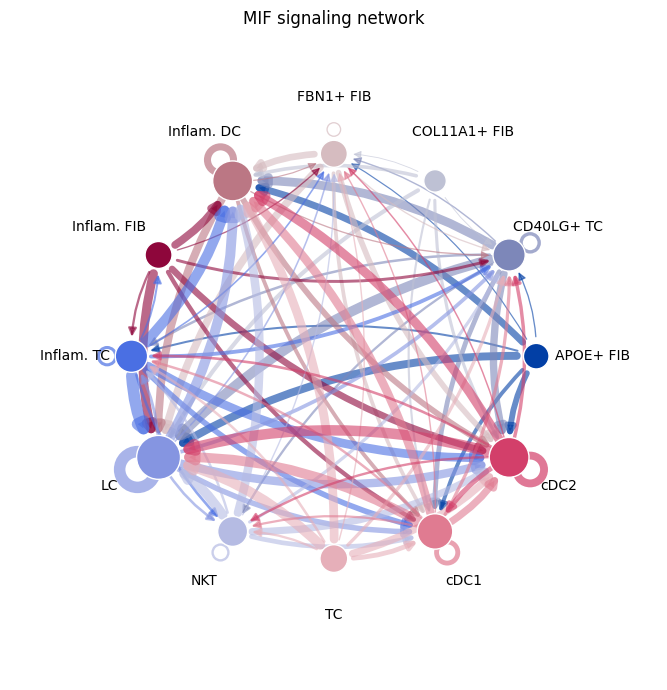

In [7]:
PATHWAY = "MIF"
ix.plot_aggregate(cc, signaling=PATHWAY, layout="circle",
                  title=f"{PATHWAY} signaling network")

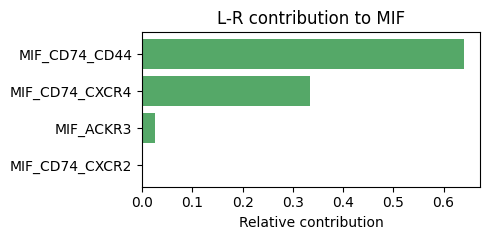

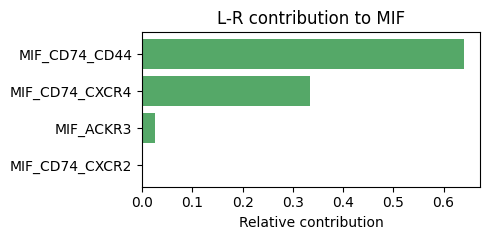

In [8]:
contrib = cc.contribution(PATHWAY)
ix.plot_contribution(contrib, title=f"L-R contribution to {PATHWAY}")

## 5. Ligand–receptor bubble plot

`subset_communication` returns the significant LR-level table; filter by sources/targets and
show the probabilities as a bubble plot. Here: signaling **from** the inflammatory fibroblast
and DC populations **to** the T-cell populations.

85 significant L-R links


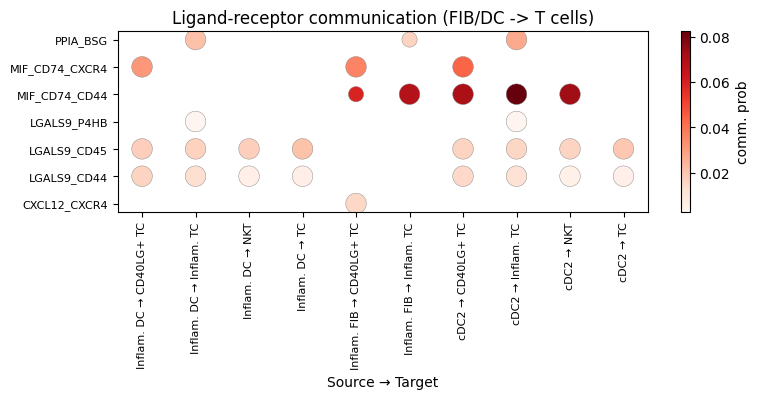

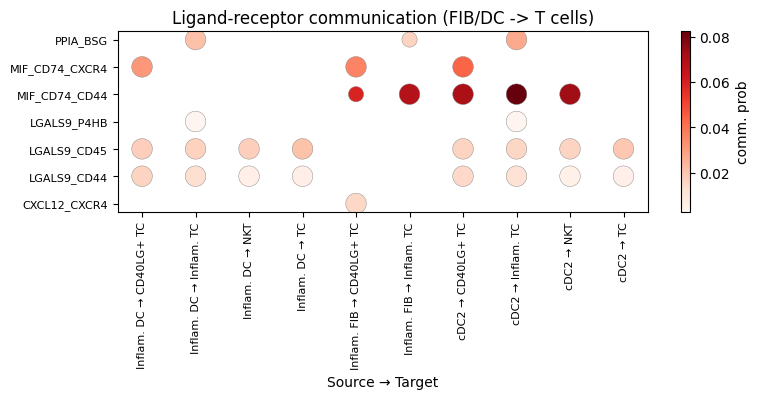

In [9]:
sources = ["Inflam. FIB", "Inflam. DC", "cDC2"]
targets = ["TC", "Inflam. TC", "CD40LG+ TC", "NKT"]
comm = cc.subset_communication(sources=sources, targets=targets)
print(f"{len(comm)} significant L-R links")
ix.plot_bubble(comm.head(30), title="Ligand-receptor communication (FIB/DC -> T cells)")

## 6. Signaling roles — network centrality

Which cell groups act as dominant **senders**, **receivers**, **mediators**, or
**influencers**? `signaling_role_pathway` gives a pathway × group role matrix (heatmap), and
`plot_signaling_role_scatter` places each group on a sender vs. receiver plane.

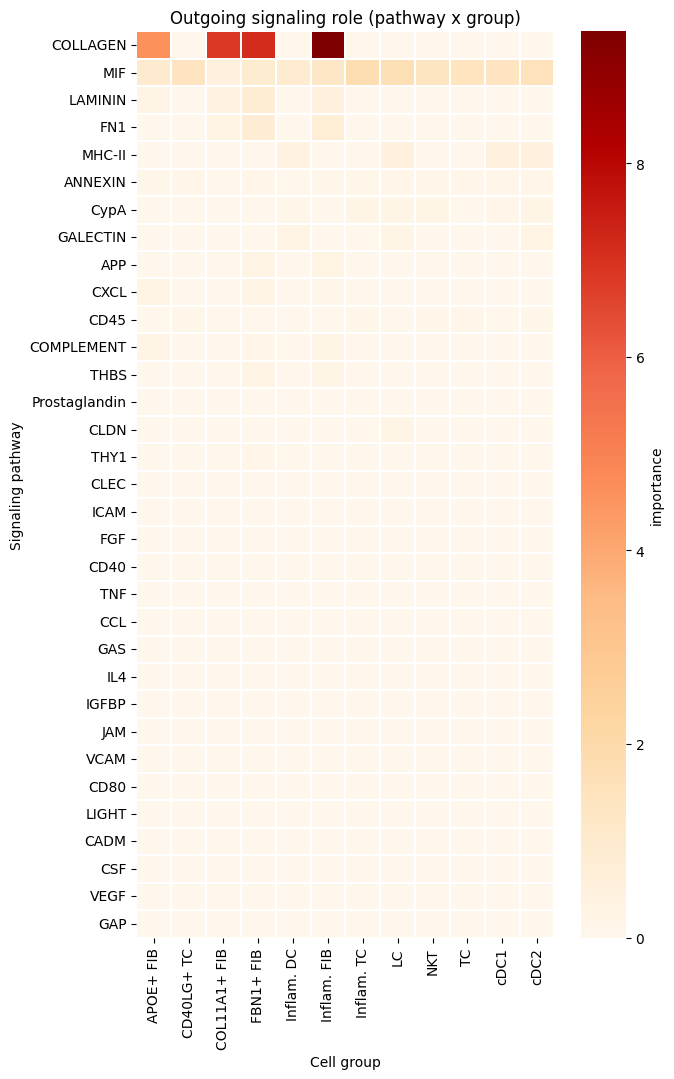

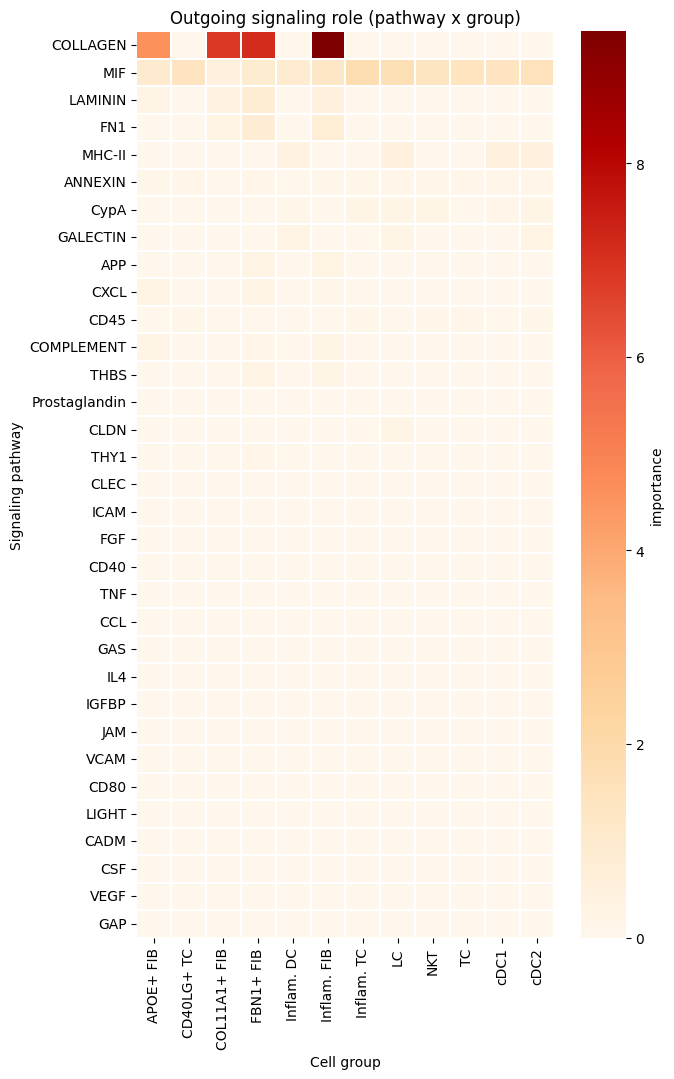

In [10]:
role_out = ix.signaling_role_pathway(cc, pattern="outgoing")
ix.plot_signaling_role_heatmap(role_out, title="Outgoing signaling role (pathway x group)")

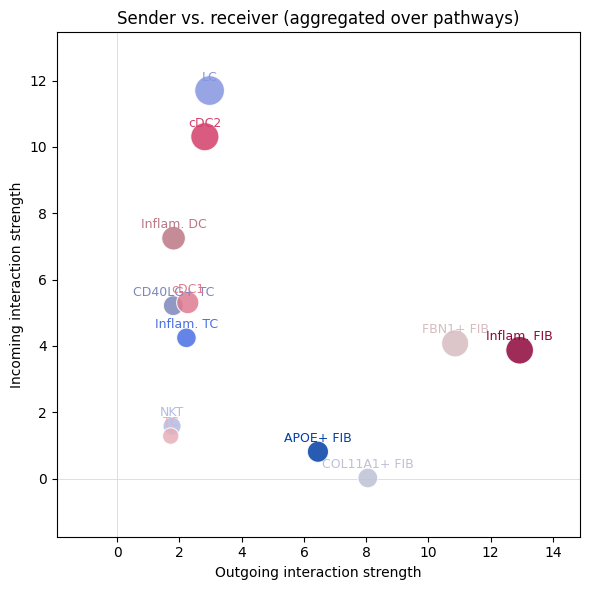

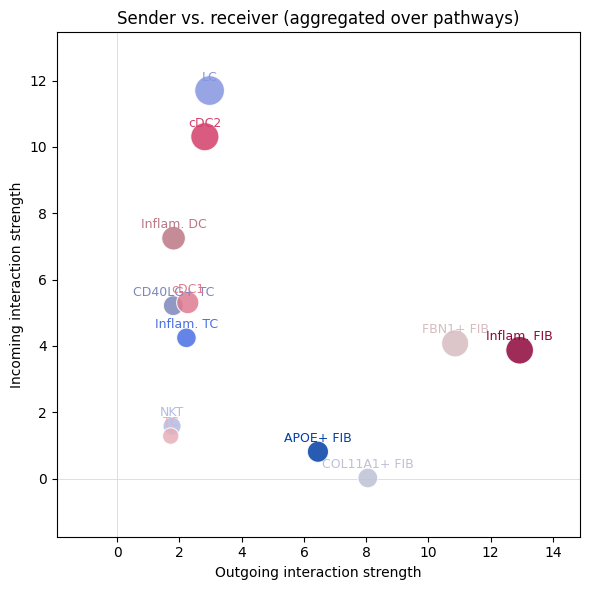

In [11]:
ix.plot_signaling_role_scatter(cc, title="Sender vs. receiver (aggregated over pathways)")

## 7. Communication patterns (NMF)

Non-negative matrix factorization groups cell populations and pathways into a small number of
coordinated **communication patterns** (CellChat's `identifyCommunicationPatterns`).
`select_k()` can help choose the number of patterns; here we use `k=3` for the outgoing signaling.

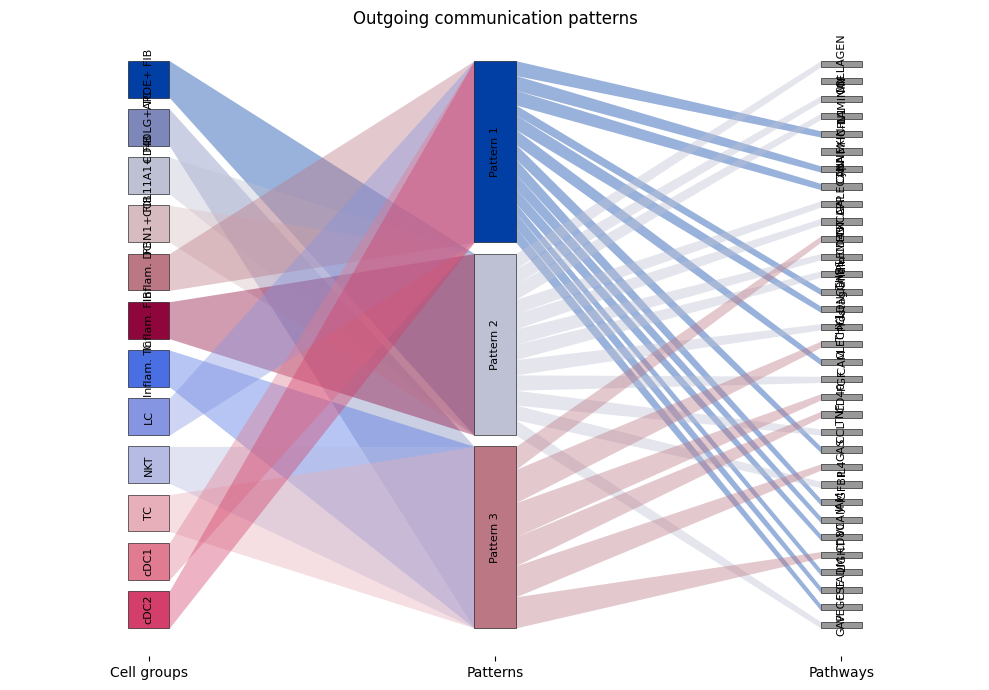

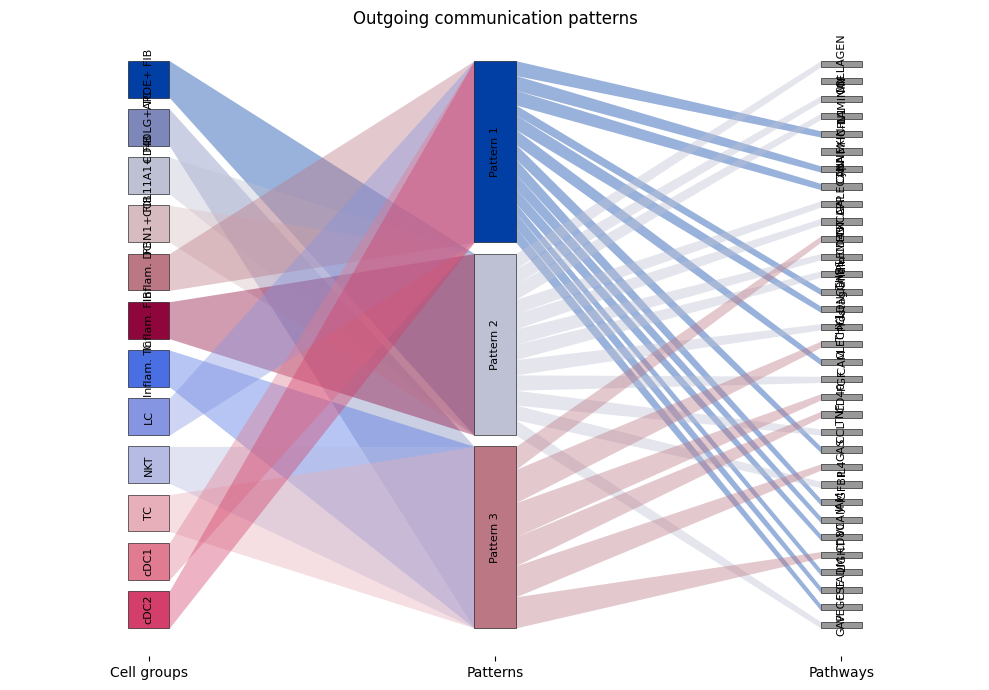

In [12]:
cc.identify_communication_patterns(pattern="outgoing", k=3, seed=0, verbose=False)
ix.plot_communication_patterns_river(cc, pattern="outgoing",
                                     title="Outgoing communication patterns")

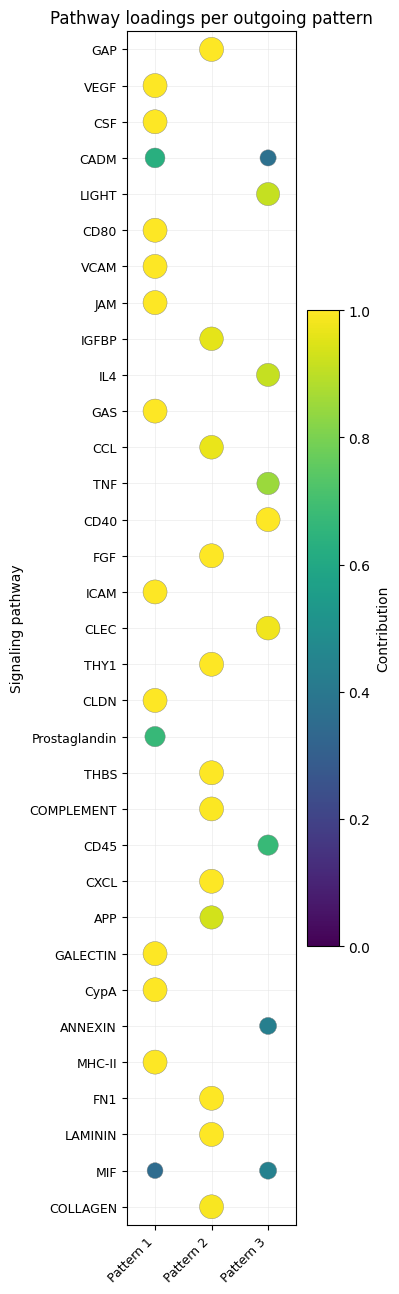

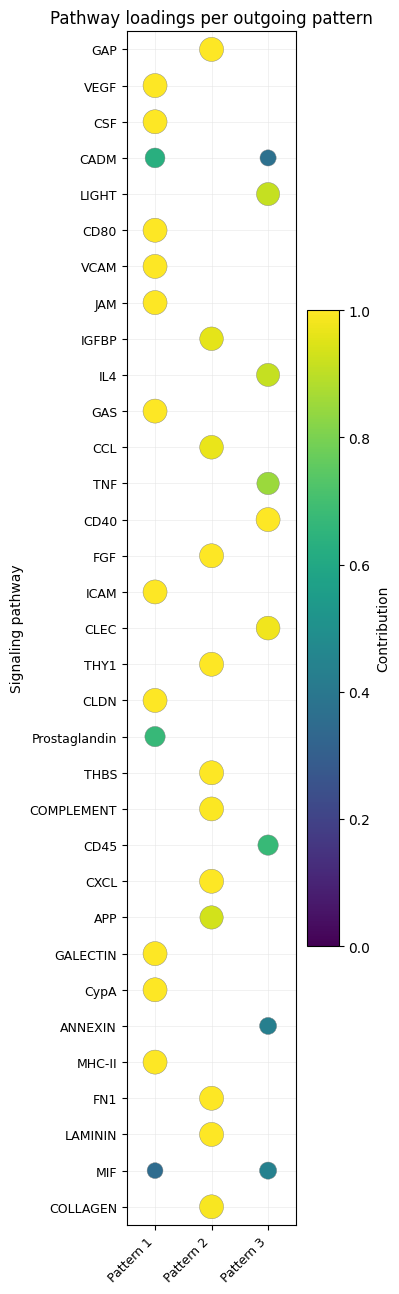

In [13]:
ix.plot_communication_patterns_dot(cc, pattern="outgoing", axis="signaling",
                                   title="Pathway loadings per outgoing pattern")

## 8. Pathway similarity manifold

Embed the signaling-pathway networks by **functional** similarity, then cluster them —
pathways that act on similar sender/receiver structure group together (CellChat's
`computeNetSimilarity` / `netEmbedding` / `netClustering`).

[interaction] computing functional pathway similarity (33 pathways, SNN k=7)
[interaction] dropping 4 disconnected pathway(s) before embedding: ['CLEC', 'CD40', 'CCL', 'IGFBP']


/home/smcheong/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/smcheong/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[interaction] embedded 29 pathways (functional) via UMAP


[interaction] inferred number of pathway clusters: k=3


[interaction] clustered 29 pathways into 3 group(s) (kmeans, functional)


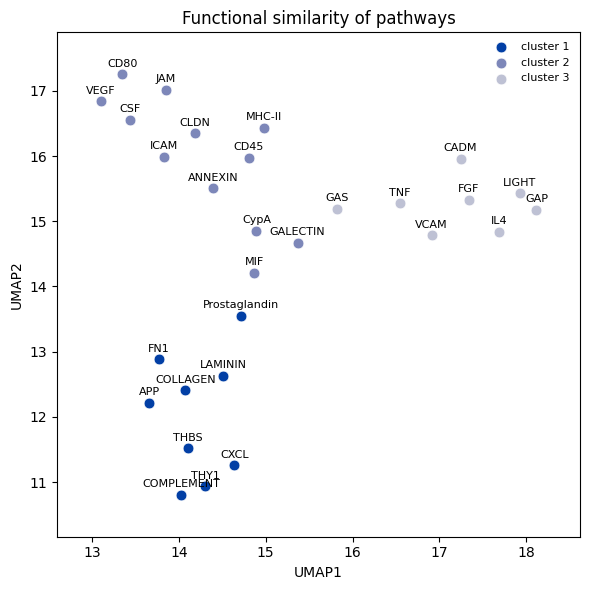

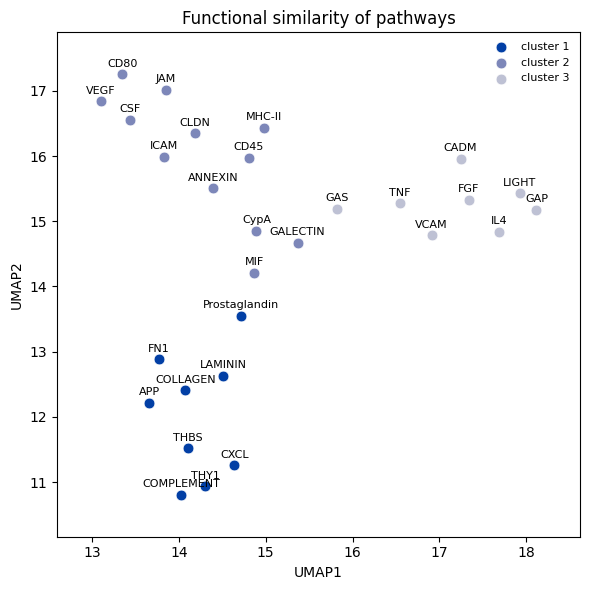

In [14]:
cc.compute_net_similarity(type="functional")
cc.net_embedding(type="functional", seed=42)
cc.net_clustering(type="functional")
ix.plot_net_embedding(cc, type="functional", title="Functional similarity of pathways")

## References

- Jin, S. *et al.* Inference and analysis of cell–cell communication using CellChat.
  *Nat. Commun.* **12**, 1088 (2021).
- CellChat: https://github.com/jinworks/CellChat

`sceleto.interaction` is a Python port of CellChat (GPL-3.0); please cite the paper above.